Revisar bien este notebook ya que cambie la definicion de T-confort, y luego la volvi a meter rapido.

In [50]:
import pandas as pd
dfs = []

df_names = [    
            'df_final_termostatos_combinaciones.csv',
            'df_final_termostatos_activados_21.csv',
            'df_final_termostatos_apagados.csv',
            'df_final_ventanas_cerradas.csv',
            'df_final_ventanas_abiertas.csv',
            'df_final_ventanas_medio.csv'    
            'df_final_H0.csv',
            'df_final_H1.csv',
            'df_final_H2.csv',
            'df_final_H3.csv',
            'df_final_H4.csv',
            'df_final_C0.csv',
            'df_final_C1.csv',
            'df_final_C2.csv',
            'df_final_C3.csv',
            'df_final_C4.csv',
            'df_final_B1.csv',
            'df_final_B2.csv',
            'df_final_B3.csv',
            'df_final_cada6_1.csv',
            'df_final_cada6_2.csv',
            'df_final_B0.csv',
            ]



for name in df_names:
    df = pd.read_csv(f"CSV/EP_RUNS/{name}", encoding="latin1")
    dfs.append(df)

In [51]:
# añadir etiqueta de run
dfs_etiquetados = []
for i, df in enumerate(dfs):
    df_copy = df.copy()
    df_copy["run_id"] = i
    dfs_etiquetados.append(df_copy)
    print(df_names[i])
    if 'termostatos_Clases_Heating' in df_copy.columns:
        print(df_copy['termostatos_Clases_Heating'].isna().sum())
    else: 
        print(f'You need to fix termostatos_Clases_Heating in {df_names[i]}')

# unir todo en un solo dataframe
df_total = pd.concat(dfs_etiquetados, ignore_index=True)

df_final_termostatos_combinaciones.csv
0
df_final_termostatos_activados_21.csv
You need to fix termostatos_Clases_Heating in df_final_termostatos_activados_21.csv
df_final_termostatos_apagados.csv
You need to fix termostatos_Clases_Heating in df_final_termostatos_apagados.csv
df_final_ventanas_cerradas.csv
You need to fix termostatos_Clases_Heating in df_final_ventanas_cerradas.csv
df_final_ventanas_abiertas.csv
You need to fix termostatos_Clases_Heating in df_final_ventanas_abiertas.csv
df_final_ventanas_medio.csv
You need to fix termostatos_Clases_Heating in df_final_ventanas_medio.csv


In [52]:
import re
import numpy as np

def get_columns(columns, key):
    
    columns_key = []
    for col in columns:
        
        if re.search(f'{key}', col, re.IGNORECASE):
            columns_key.append(col)
    
    # Prints
    print(f'{key} len = {len(columns_key)}')
    
    return columns_key

In [53]:
Termostatos = get_columns(df_total.columns, 'termostatos')

Termostatos_heating = get_columns(Termostatos, 'Heating')
Termostatos_cooling = get_columns(Termostatos, 'Cooling')

termostatos len = 16
Heating len = 8
Cooling len = 8


In [54]:
for run_id, group in df_total.groupby("run_id"):
    print(f'Min/Max heating run_id{run_id}: ', 
         f'\nMin\n: {group[Termostatos_heating].min()}\n',
          f'Max\n: {group[Termostatos_heating].max()}','\n')
    
    print(f'\nMin/Max Cooling run_id{run_id}: ', 
         f'Min\n: {group[Termostatos_cooling].min()}\n',
          f'Max\n: {group[Termostatos_cooling].max()}','\n')

Min/Max heating run_id0:  
Min
: termostatos_Banos_Heating        15.0
termostatos_Clases_Heating       15.0
termostatos_Hall_Heating         16.0
termostatos_Pasillo_Heating      14.0
termostatos_Taller_Heating       16.0
termostatos_Clases101_Heating    15.0
termostatos_Clases102_Heating    14.0
termostatos_Clases103_Heating    16.0
dtype: float64
 Max
: termostatos_Banos_Heating        26.7
termostatos_Clases_Heating       26.7
termostatos_Hall_Heating         26.7
termostatos_Pasillo_Heating      26.7
termostatos_Taller_Heating       26.7
termostatos_Clases101_Heating    26.7
termostatos_Clases102_Heating    26.7
termostatos_Clases103_Heating    26.7
dtype: float64 


Min/Max Cooling run_id0:  Min
: termostatos_Banos_Cooling        24.0
termostatos_Clases_Cooling       24.0
termostatos_Hall_Cooling         20.0
termostatos_Pasillo_Cooling      24.0
termostatos_Taller_Cooling       20.0
termostatos_Clases101_Cooling    24.0
termostatos_Clases102_Cooling    21.0
termostatos_Clases103

In [55]:
#OJO en algunos runs falto incluir termostatos de las clases.
df_total.isna().sum()[80:100]

surf_Temp_outside_Hall_suelo                0
surf_Temp_outside_Clases_Taller             0
surf_Temp_outside_Clases_exteriores         0
surf_Temp_outside_Clases_techo              0
surf_Temp_outside_Clases_puerta             0
surf_Temp_outside_Clases_suelo              0
surf_Temp_outside_Banos_Taller              0
surf_Temp_outside_Banos_exteriores          0
surf_Temp_outside_Banos_techo               0
surf_Temp_outside_Banos_puerta              0
surf_Temp_outside_Banos_suelo               0
Wind_Speed                                  0
Precipitarion_Depth                         0
solar_radiation                             0
Illuminance                                 0
termostatos_Banos_Heating                   0
termostatos_Banos_Cooling                   0
termostatos_Clases_Heating             262800
termostatos_Clases_Cooling             262800
termostatos_Hall_Heating                    0
dtype: int64

## Checkear Colinearidades por grupos de 

Voy a buscar todas las Temperaturas superficiales que tengan que ver con el taller.

In [61]:
#temperaturas superficiales exteriores en zonas
suf_temps_outsides = get_columns(df_total.columns, 'surf_Temp_outside')

#temperaturas superficiales menias interiores en zonas
suf_temps_inside_mean = get_columns(df_total.columns, 'Tsurf_mean')

surf_Temp_outside len = 21
Tsurf_mean len = 6


In [62]:
import seaborn as sns  # For more aesthetic and informative plots
import matplotlib.pyplot as plt

def check_correlation_Tsurf(zone):
    surf_temps_outsides_zone = get_columns(suf_temps_outsides, zone)
    suf_temps_inside_mean_zone = get_columns(suf_temps_inside_mean, zone)

    Surface_Face_Temperature_zone = surf_temps_outsides_zone+suf_temps_inside_mean_zone

    # Set the figure size
    plt.figure(figsize=(6, 6))

    # Plot the correlation matrix with annotations
    sns.heatmap(df_total[Surface_Face_Temperature_zone].corr(), 
                annot=True,         # Show correlation coefficients in the cells
                fmt=".2f",          # Format numbers to 2 decimal places
                square=True,        # Make the heatmap square
                linewidths=0.5,     # Add lines between cells
                cbar_kws={"shrink": 0.8})  # Shrink color bar a bit

    # Display the plot
    plt.title("Correlation Matrix of df_final", fontsize=14)
    plt.tight_layout()
    plt.show()

    print('surf_temps_outsides_Taller: \n', surf_temps_outsides_zone ,'\n')

    print('suf_temps_inside_mean_Taller: ', suf_temps_inside_mean_zone)
    
    return surf_temps_outsides_zone, suf_temps_inside_mean_zone

Taller len = 3
Taller len = 2


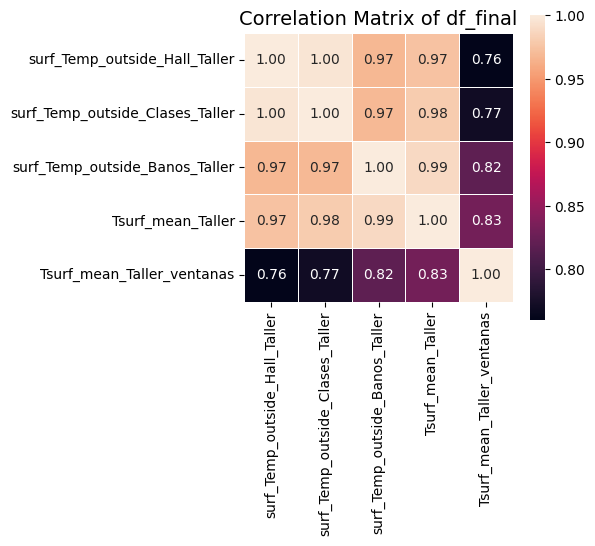

surf_temps_outsides_Taller: 
 ['surf_Temp_outside_Hall_Taller', 'surf_Temp_outside_Clases_Taller', 'surf_Temp_outside_Banos_Taller'] 

suf_temps_inside_mean_Taller:  ['Tsurf_mean_Taller', 'Tsurf_mean_Taller_ventanas']


In [63]:
surf_temps_outsides_Taller, suf_temps_inside_mean_Taller = check_correlation_Tsurf('Taller')

Como podemos ver hay una correlacion muy alta entre todas las columnas superficiales, entonces creare una sola variable que las agregue.

In [64]:
df_total["T_confort"] = 0.5 * df_total['Air_Temp_Taller'] + 0.5 * df_total['Tsurf_mean_Taller']
targets = ['T_confort','Humedad_Taller','CO2_Taller']



Haré lo mismo con todas las zonas

<Axes: >

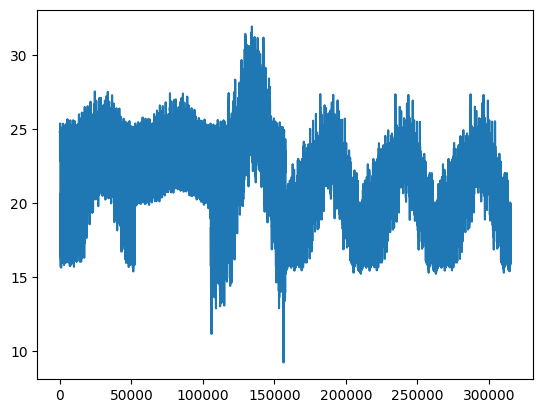

In [65]:
df_total["T_confort"].plot()

Banos len = 6
Banos len = 1


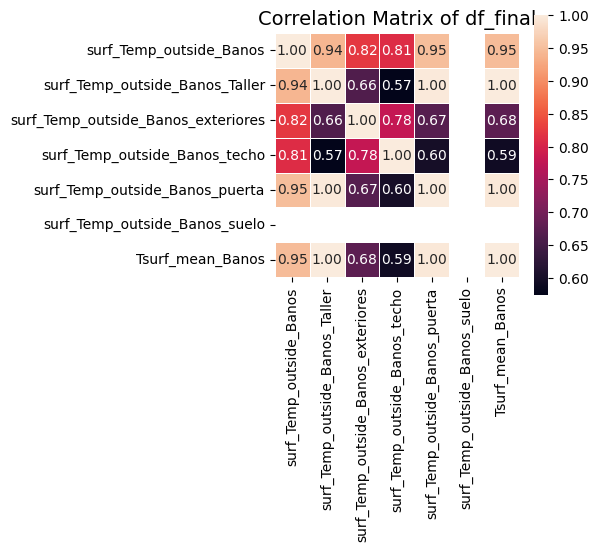

surf_temps_outsides_Taller: 
 ['surf_Temp_outside_Banos', 'surf_Temp_outside_Banos_Taller', 'surf_Temp_outside_Banos_exteriores', 'surf_Temp_outside_Banos_techo', 'surf_Temp_outside_Banos_puerta', 'surf_Temp_outside_Banos_suelo'] 

suf_temps_inside_mean_Taller:  ['Tsurf_mean_Banos']


In [66]:
#Baños
surf_temps_outsides_Banos, suf_temps_inside_mean_Banos = check_correlation_Tsurf('Banos')

Clases len = 6
Clases len = 0


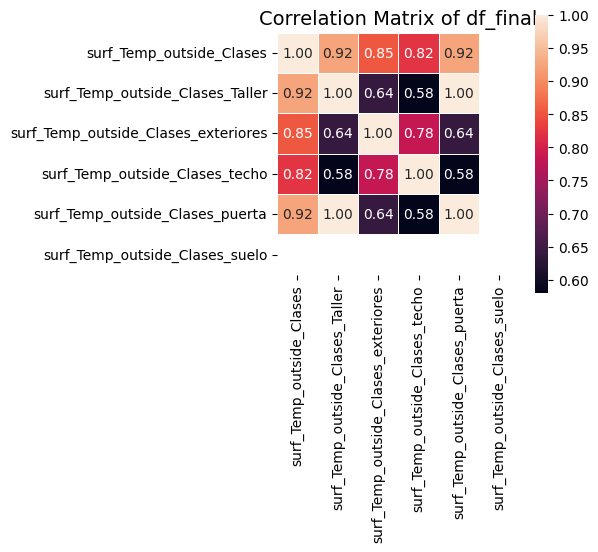

surf_temps_outsides_Taller: 
 ['surf_Temp_outside_Clases', 'surf_Temp_outside_Clases_Taller', 'surf_Temp_outside_Clases_exteriores', 'surf_Temp_outside_Clases_techo', 'surf_Temp_outside_Clases_puerta', 'surf_Temp_outside_Clases_suelo'] 

suf_temps_inside_mean_Taller:  []


In [68]:
#Clases

surf_temps_outsides_Clases, suf_temps_inside_mean_Clases = check_correlation_Tsurf('Clases')

Hall len = 5
Hall len = 1


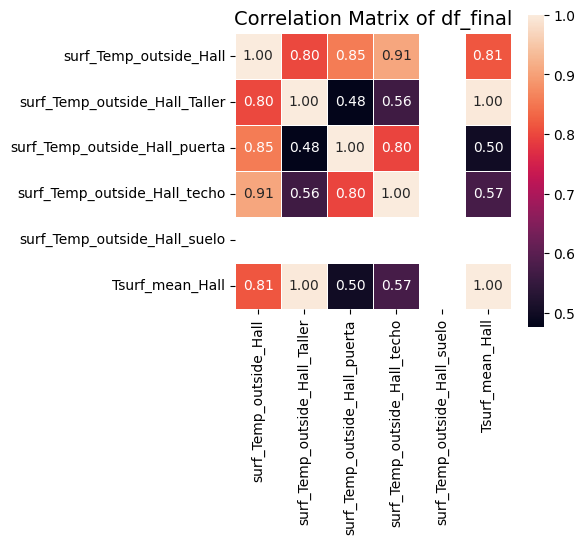

surf_temps_outsides_Taller: 
 ['surf_Temp_outside_Hall', 'surf_Temp_outside_Hall_Taller', 'surf_Temp_outside_Hall_puerta', 'surf_Temp_outside_Hall_techo', 'surf_Temp_outside_Hall_suelo'] 

suf_temps_inside_mean_Taller:  ['Tsurf_mean_Hall']


In [69]:
#Halls
surf_temps_outsides_Hall,suf_temps_inside_mean_Hall = check_correlation_Tsurf('Hall')

Pasillo len = 4
Pasillo len = 0


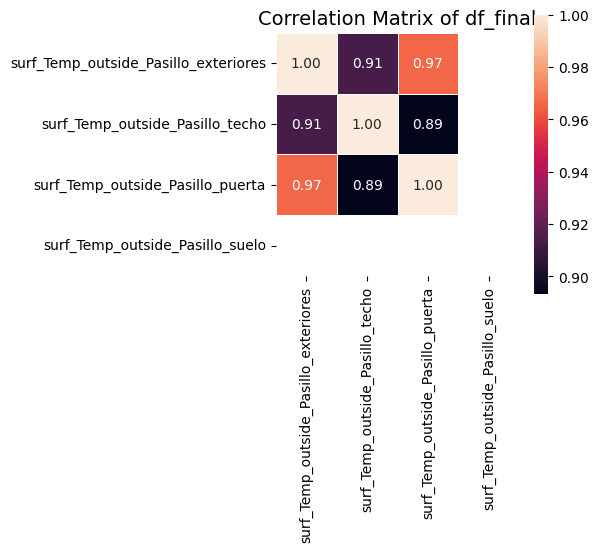

surf_temps_outsides_Taller: 
 ['surf_Temp_outside_Pasillo_exteriores', 'surf_Temp_outside_Pasillo_techo', 'surf_Temp_outside_Pasillo_puerta', 'surf_Temp_outside_Pasillo_suelo'] 

suf_temps_inside_mean_Taller:  []


In [70]:
#Pasillo
surf_temps_outsides_Pasillo,suf_temps_inside_mean_Pasillo = check_correlation_Tsurf('Pasillo')

In [71]:
Termostatos = get_columns(df_total.columns, 'termostatos')

Termostatos_heating = get_columns(Termostatos, 'Heating')
Termostatos_cooling = get_columns(Termostatos, 'Cooling')

termostatos len = 16
Heating len = 8
Cooling len = 8


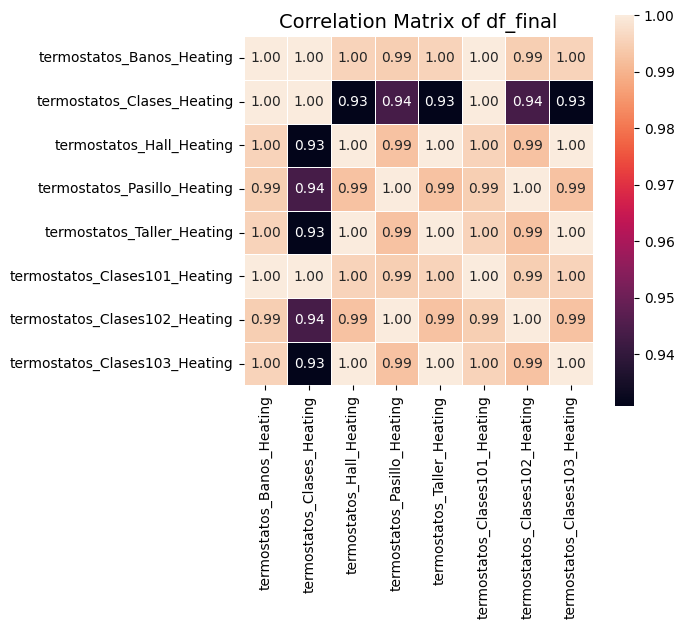

In [73]:
import seaborn as sns  # For more aesthetic and informative plots

# Set the figure size
plt.figure(figsize=(7, 7))

# Plot the correlation matrix with annotations
sns.heatmap(df_total[Termostatos_heating].corr(), 
            annot=True,         # Show correlation coefficients in the cells
            fmt=".2f",          # Format numbers to 2 decimal places
            square=True,        # Make the heatmap square
            linewidths=0.5,     # Add lines between cells
            cbar_kws={"shrink": 0.8})  # Shrink color bar a bit

# Display the plot
plt.title("Correlation Matrix of df_final", fontsize=14)
plt.tight_layout()
plt.show()

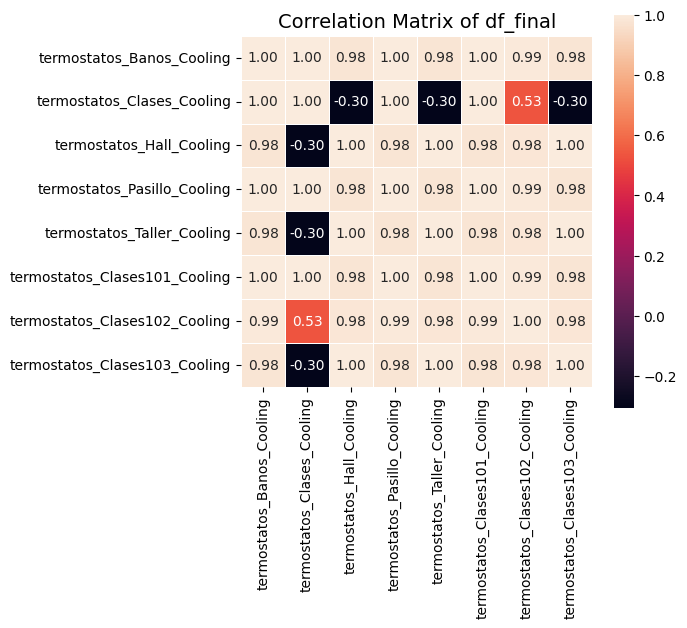

In [74]:
import seaborn as sns  # For more aesthetic and informative plots

# Set the figure size
plt.figure(figsize=(7, 7))

# Plot the correlation matrix with annotations
sns.heatmap(df_total[Termostatos_cooling].corr(), 
            annot=True,         # Show correlation coefficients in the cells
            fmt=".2f",          # Format numbers to 2 decimal places
            square=True,        # Make the heatmap square
            linewidths=0.5,     # Add lines between cells
            cbar_kws={"shrink": 0.8})  # Shrink color bar a bit

# Display the plot
plt.title("Correlation Matrix of df_final", fontsize=14)
plt.tight_layout()
plt.show()

In [77]:
df = df_total.copy()


In [78]:
df.shape, df_total.shape

((315360, 113), (315360, 113))

In [79]:
# import seaborn as sns  # For more aesthetic and informative plots

# # Set the figure size
# plt.figure(figsize=(15, 15))

# # Plot the correlation matrix with annotations
# sns.heatmap(df[df.columns[2:]].corr(), 
# #             annot=True,         # Show correlation coefficients in the cells
#             fmt=".2f",          # Format numbers to 2 decimal places
#             square=True,        # Make the heatmap square
#             linewidths=0.5,     # Add lines between cells
#             cbar_kws={"shrink": 0.8})  # Shrink color bar a bit

# # Display the plot
# plt.title("Correlation Matrix of df_final", fontsize=14)
# plt.tight_layout()
# plt.show()

Voy a investigar si hay mas correlaciones fuertes que puedo agrupar.

In [80]:
Air_temp = get_columns(df.columns, 'Air_temp')
Air_temp
# suf_temps_inside_mean = get_columns(df_total.columns, 'Tsurf_mean')

Air_temp len = 7


['Air_temp_banos',
 'Air_temp_clase_101',
 'Air_temp_clase_102',
 'Air_temp_clase_103',
 'Air_Temp_Taller',
 'Air_Temp_Pasillo',
 'Air_Temp_Hall']

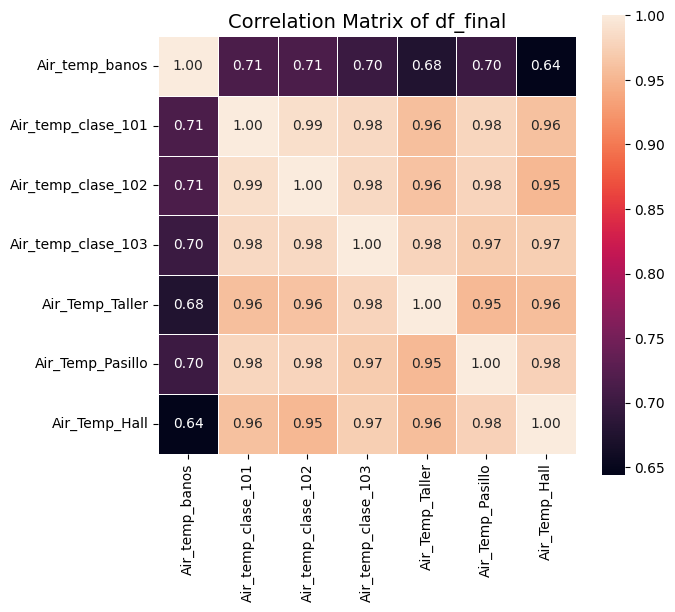

In [81]:
import seaborn as sns  # For more aesthetic and informative plots

# Set the figure size
plt.figure(figsize=(7, 7))

# Plot the correlation matrix with annotations
sns.heatmap(df[Air_temp].corr(), 
            annot=True,         # Show correlation coefficients in the cells
            fmt=".2f",          # Format numbers to 2 decimal places
            square=True,        # Make the heatmap square
            linewidths=0.5,     # Add lines between cells
            cbar_kws={"shrink": 0.8})  # Shrink color bar a bit

# Display the plot
plt.title("Correlation Matrix of df_final", fontsize=14)
plt.tight_layout()
plt.show()

In [82]:
df['Air_temp_clases_pasillo_Hall'] = df[Air_temp[1:]].mean(axis = 1)

df = df.drop(['Air_temp_clase_101',
             'Air_temp_clase_102',
             'Air_temp_clase_103',
             'Air_Temp_Pasillo',
             'Air_Temp_Hall'],axis = 1)

In [85]:
CO2 = get_columns(df.columns, 'CO2')
CO2

CO2 len = 5


['CO2_Banos', 'CO2_Clases', 'CO2_Hall', 'CO2_Pasillo', 'CO2_Taller']

In [86]:
# import seaborn as sns  # For more aesthetic and informative plots

# # Set the figure size
# plt.figure(figsize=(5, 5))

# # Plot the correlation matrix with annotations
# sns.heatmap(df[CO2].corr(), 
#             annot=True,         # Show correlation coefficients in the cells
#             fmt=".2f",          # Format numbers to 2 decimal places
#             square=True,        # Make the heatmap square
#             linewidths=0.5,     # Add lines between cells
#             cbar_kws={"shrink": 0.8})  # Shrink color bar a bit

# # Display the plot
# plt.title("Correlation Matrix of df_final", fontsize=14)
# plt.tight_layout()
# plt.show()

In [87]:
df['CO2_clases_bano'] = df[['CO2_Banos', 'CO2_Clases']].mean(axis = 1)
df['CO2_hall_pasillo'] = df[['CO2_Hall', 'CO2_Pasillo']].mean(axis = 1)

df = df.drop(CO2[:-1],axis = 1)

In [1]:
Heat_Flux = get_columns(df.columns, 'Heat_Flux')

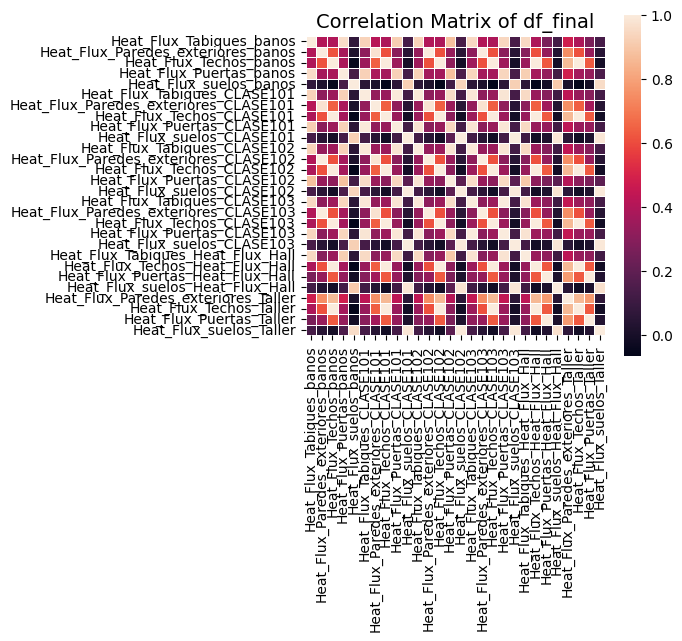

In [89]:
import seaborn as sns  # For more aesthetic and informative plots

# Set the figure size
plt.figure(figsize=(7, 7))

# Plot the correlation matrix with annotations
sns.heatmap(df[Heat_Flux].corr(), 
#             annot=True,         # Show correlation coefficients in the cells
            fmt=".2f",          # Format numbers to 2 decimal places
            square=True,        # Make the heatmap square
            linewidths=0.5,     # Add lines between cells
            cbar_kws={"shrink": 0.8})  # Shrink color bar a bit

# Display the plot
plt.title("Correlation Matrix of df_final", fontsize=14)
plt.tight_layout()
plt.show()

In [93]:
df["run_id"].unique()

array([0, 1, 2, 3, 4, 5], dtype=int64)

In [94]:
for run_id, group in df.groupby("run_id"):
    print(run_id)
#     if run_id>7:
    group.to_csv(f'CSV/df_runs_{run_id}.csv')
    

0
1
2
3
4
5


In [95]:
# import pandas as pd
# import numpy as np

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler


# # Features
# X = df.drop(columns=targets +
#            ['datetime'])

# X = X.ffill().bfill() #rellenar nans

# y = df[targets]

# # Split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # Escalado (CLAVE para L1/L2)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [96]:
# X.shape

### Reduccion del espacio

In [97]:
# from sklearn.linear_model import MultiTaskLassoCV

# lasso = MultiTaskLassoCV(
#     cv=5,
#     random_state=42,
#     n_alphas=50,
#     max_iter=5000
# )

# lasso.fit(X_train_scaled, y_train)

# print("Alpha óptimo:", lasso.alpha_)

In [ ]:
# coef_lasso = pd.DataFrame(
#     lasso.coef_,
#     columns=X.columns,
#     index=targets
# )

# # Importancia global
# importance_lasso = coef_lasso.abs().mean(axis=0).sort_values(ascending=False)

In [ ]:
# selected_features_lasso = importance_lasso[importance_lasso > 0].index.tolist()

# print("Número de variables seleccionadas por lasso:", len(selected_features_lasso))
# selected_features_lasso

In [ ]:
# from sklearn.linear_model import RidgeCV

# ridge = RidgeCV(
#     alphas=np.logspace(-3, 3, 50),
#     cv=5
# )

# ridge.fit(X_train_scaled, y_train)

# print("Alpha óptimo:", ridge.alpha_)

In [ ]:
# coef_ridge = pd.DataFrame(
#     ridge.coef_,
#     columns=X.columns,
#     index=targets
# )

# importance_ridge = coef_ridge.abs().mean(axis=0).sort_values(ascending=False)

In [ ]:
# # En Ridge la penalizacion es menor, y los coeficientes no alcanzan el limite 0 exactamente cuando aumento alpha.
# #tengo que definir un threshold para elegir los importantes, por ejemplo el quantile 0.9

# q = 0.1
# threshold = importance_ridge.quantile(q)
# print(f'{q*100}% de los coef en Ridge están por debajo de {threshold}')
# selected_features_ridge = importance_ridge[importance_ridge > threshold]

# print("Número de variables seleccionadas por Ridge:", len(selected_features_ridge))

# selected_features_ridge

In [ ]:
# selected_features_ridge= selected_features_ridge.index.tolist()

In [ ]:
# import warnings
# import matplotlib.pyplot as plt
# from sklearn.linear_model import MultiTaskLasso

# warnings.filterwarnings("ignore", category=UserWarning)
# alphas = np.logspace(-3, 1, 50)
# coefs = []

# for a in alphas:
#     model = MultiTaskLasso(alpha=a, max_iter=5000)
#     model.fit(X_train_scaled, y_train)
#     coefs.append(np.mean(np.abs(model.coef_), axis=0))

# coefs = np.array(coefs)

# plt.figure(figsize=(10,6))
# for i in range(coefs.shape[1]):
#     plt.plot(alphas, coefs[:, i])

# plt.xscale("log")
# plt.xlabel("lambda (alpha)")
# plt.ylabel("coeficientes medios")
# plt.title("Lasso path")
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# from sklearn.linear_model import Ridge

# alphas = np.logspace(-3, 1, 50)
# coefs = []

# for a in alphas:
#     model = Ridge(alpha=a, max_iter=5000)
#     model.fit(X_train_scaled, y_train)
#     coefs.append(np.mean(np.abs(model.coef_), axis=0))

# coefs = np.array(coefs)

# plt.figure(figsize=(10,6))
# for i in range(coefs.shape[1]):
#     plt.plot(alphas, coefs[:, i])

# plt.xscale("log")
# plt.xlabel("lambda (alpha)")
# plt.ylabel("coeficientes medios")
# plt.title("Ridge path")
# plt.show()

- Ridge penaliza los coeficientes pero no los hace cero → mantiene todas las variables. Es decir Ridge = “suaviza”
- Lasso penaliza más agresivamente → hace que algunos coeficientes sean exactamente 0 → hace selección de variables. Es decir Lasso = “recorta”
 

##### Cuándo usar cada uno
- Usar Ridge si:
    - Todas las variables aportan algo
    - Hay mucha multicolinealidad (muy típico en sensores térmicos)
    - Se quiere estabilidad

En Somorrostro esto pasa mucho: temperaturas, superficies, etc están correlacionadas.

- Usar Lasso si:
    - Muchas variables son ruido
    - Se quiere ganar interpretabilidad del modelo
    - Se Necesita reducir dimensionalidad

###### Problema importante del Lasso

Cuando hay variables muy correlacionadas: Lasso elige una y descarta el resto
Esa elección puede ser inestable

Ridge en cambio: reparte pesos entre ellas. 


Pero Por otro lado MultitaskLasso entrena los diferente targets lal mismo tiempo y ademas mira como estos interaccionan entre si, mientras que Ridge no. 

### PCAs

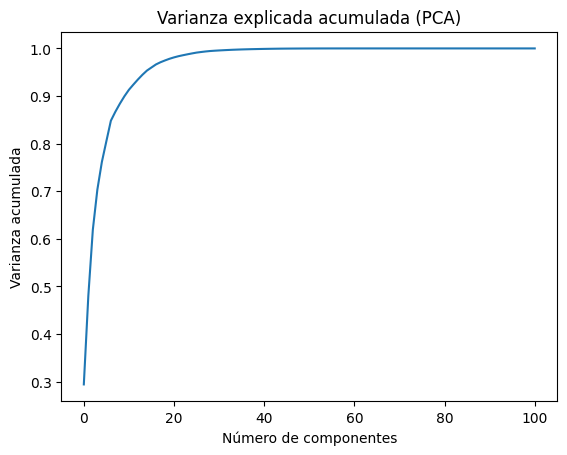

In [143]:
# from sklearn.decomposition import PCA
# #PCA 

# pca = PCA()
# X_pca = pca.fit_transform(X_train_scaled)

# import matplotlib.pyplot as plt

# plt.figure()
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel("Número de componentes")
# plt.ylabel("Varianza acumulada")
# plt.title("Varianza explicada acumulada (PCA)")
# plt.show()

In [144]:
# n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1

# print("Número de componentes:", n_components)

Número de componentes: 15


In [145]:
# #combinar todo:
    
# X_lasso = X[selected_features_lasso]

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_lasso)

# pca = PCA()
# pca.fit(X_scaled)

# loadings_lasso = pd.DataFrame(
#     pca.components_,
#     columns=X_lasso.columns
# )

# selection_lasso_PCA = loadings_lasso.iloc[0].abs().sort_values(ascending=False)>0.05
# selection_lasso_PCA

CO2_Clases                                True
Electricity_Pasillo                       True
Electricity_Hall                          True
CO2_Banos                                 True
Occupancy_Taller                          True
Occupancy_Banos                           True
Electricity_Taller                        True
solar_radiation                           True
Occupancy_Hall                            True
Occupancy_Pasillo                         True
Gas_Other                                 True
CO2_Pasillo                               True
Heat_Flux_Tabiques_banos                  True
CO2_Hall                                  True
Window_Taller                             True
Heat_Flux_Paredes_exteriores_CLASE102     True
Heat_Flux_Techos_CLASE103                 True
Heat_Flux_Techos_CLASE102                 True
surf_Temp_outside_Banos_exteriores        True
termostatos_Clases_Cooling                True
Air_temp_clases_pasillo_Hall              True
surf_Temp_out

In [146]:
# features_lasso_PCA = loadings_lasso.iloc[0].abs().sort_values(ascending=False)[selection_lasso_PCA.values].keys().tolist()
# features_lasso_PCA

['CO2_Clases',
 'Electricity_Pasillo',
 'Electricity_Hall',
 'CO2_Banos',
 'Occupancy_Taller',
 'Occupancy_Banos',
 'Electricity_Taller',
 'solar_radiation',
 'Occupancy_Hall',
 'Occupancy_Pasillo',
 'Gas_Other',
 'CO2_Pasillo',
 'Heat_Flux_Tabiques_banos',
 'CO2_Hall',
 'Window_Taller',
 'Heat_Flux_Paredes_exteriores_CLASE102',
 'Heat_Flux_Techos_CLASE103',
 'Heat_Flux_Techos_CLASE102',
 'surf_Temp_outside_Banos_exteriores',
 'termostatos_Clases_Cooling',
 'Air_temp_clases_pasillo_Hall',
 'surf_Temp_outside_Banos_puerta',
 'Window_Hall']

In [169]:
# #combinar todo:
# # selected_features_ridge = selected_features_ridge.keys().tolist()

# X_ridge = X[selected_features_ridge]

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_ridge)

# pca = PCA()
# pca.fit(X_scaled)

# loadings_ridge = pd.DataFrame(
#     pca.components_,
#     columns=X_ridge.columns
# )

# loadings_ridge.iloc[0].abs().sort_values(ascending=False)

# selection_ridge_PCA = loadings_ridge.iloc[0].abs().sort_values(ascending=False)>0.05
# selection_ridge_PCA

surf_Temp_outside_Hall              True
surf_Temp_outside_Pasillo_techo     True
surf_Temp_outside_Hall_techo        True
surf_Temp_outside_Clases_techo      True
surf_Temp_outside_Banos_techo       True
                                   ...  
termostatos_Clases103_Cooling      False
termostatos_Hall_Cooling           False
termostatos_Taller_Cooling         False
run_id                             False
termostatos_Clases_Heating         False
Name: 0, Length: 90, dtype: bool

In [180]:
# features_ridge_PCA = loadings_ridge.iloc[0].abs().sort_values(ascending=False)[selection_ridge_PCA.values].keys().tolist()
# features_ridge_PCA

['surf_Temp_outside_Hall',
 'surf_Temp_outside_Pasillo_techo',
 'surf_Temp_outside_Hall_techo',
 'surf_Temp_outside_Clases_techo',
 'surf_Temp_outside_Banos_techo',
 'surf_Temp_outside_Pasillo_exteriores',
 'surf_Temp_outside_Pasillo_puerta',
 'surf_Temp_outside_Hall_puerta',
 'surf_Temp_outside_Clases',
 'surf_Temp_outside_Banos',
 'solar_radiation',
 'Tsurf_mean_Taller_ventanas',
 'Tsurf_mean_Paillo_ventanas',
 'Illuminance',
 'CO2_Clases',
 'surf_Temp_outside_Clases_puerta',
 'Tsurf_mean_Hall',
 'surf_Temp_outside_Banos_puerta',
 'Tsurf_mean_Paillo',
 'T_radiant_Taller_outside',
 'surf_Temp_outside_Clases_exteriores',
 'Electricity_Clases',
 'Tsurf_mean_Banos',
 'surf_Temp_outside_Banos_exteriores',
 'Electricity_Pasillo',
 'Electricity_Hall',
 'Air_temp_banos',
 'CO2_Banos',
 'Electricity_Taller',
 'Occupancy_Taller',
 'Occupancy_Clases',
 'Occupancy_Banos',
 'Electricity_Banos',
 'Window_Clases',
 'Air_temp_clases_pasillo_Hall',
 'Occupancy_Pasillo',
 'Occupancy_Hall',
 'Heat_Flux

Loq nue podemos ver son lascomponentes de la PCA1 en el espacio de features. Podemos todas las componentes implcadas en la direccion mas importante. 

In [181]:
# np.save(f'selected_features_lasso_2_runs_{run_id}.np',selected_features_lasso)
# np.save(f'selected_features_ridge_2_runs_{run_id}.np',selected_features_ridge)

In [182]:
# np.save(f'features_lasso_PCA_2_runs_{run_id}.np',features_lasso_PCA)
# np.save(f'features_rdige_PCA_2_runs_{run_id}.np',features_ridge_PCA)

In [807]:
# df = df.drop('Unnamed: 0',axis = 1)

In [808]:
# df['run_id'].unique()

array([5], dtype=int64)

20

In [809]:
# run_id =6
# df.to_csv(f'CSV/df_runs_{run_id}.csv')

In [415]:
# df.isna().sum()[50:]

Heat_Flux_Puertas_CLASE103              0
Heat_Flux_suelos_CLASE103               0
Heat_Flux_Tabiques_Heat_Flux_Hall       0
Heat_Flux_Techos_Heat_Flux_Hall         0
Heat_Flux_Puertas_Heat_Flux_Hall        0
Heat_Flux_suelos_Heat_Flux_Hall         0
Heat_Flux_Paredes_exteriores_Taller     0
Heat_Flux_Techos_Taller                 0
Heat_Flux_Puertas_Taller                0
Heat_Flux_suelos_Taller                 0
surf_Temp_outside_Banos                 0
surf_Temp_outside_Clases                0
surf_Temp_outside_Hall                  0
surf_Temp_outside_Pasillo_exteriores    0
surf_Temp_outside_Pasillo_techo         0
surf_Temp_outside_Pasillo_puerta        0
surf_Temp_outside_Pasillo_suelo         0
surf_Temp_outside_Hall_Taller           0
surf_Temp_outside_Hall_puerta           0
surf_Temp_outside_Hall_techo            0
surf_Temp_outside_Hall_suelo            0
surf_Temp_outside_Clases_Taller         0
surf_Temp_outside_Clases_exteriores     0
surf_Temp_outside_Clases_techo    